<div style="
  background: linear-gradient(145deg, #0f172a, #1e293b);
  border: 4px solid transparent;
  border-radius: 14px;
  padding: 18px 22px;
  margin: 12px 0;
  font-size: 26px;
  font-weight: 600;
  color: #f8fafc;
  box-shadow: 0 6px 14px rgba(0,0,0,0.25);
  background-clip: padding-box;
  position: relative;
">
  <div style="
    position: absolute;
    inset: 0;
    padding: 4px;
    border-radius: 14px;
    background: linear-gradient(90deg, #06b6d4, #3b82f6, #8b5cf6);
    -webkit-mask: 
      linear-gradient(#fff 0 0) content-box, 
      linear-gradient(#fff 0 0);
    -webkit-mask-composite: xor;
    mask-composite: exclude;
    pointer-events: none;
  "></div>
  <b>03. 📈 Automated Trading Backtesting Engine</b>
</div>


### 📌 Project Overview
In this project, we implement a financial strategy backtesting engine using real-world stock market indices like Nifty 50 (`^NSEI`) or Sensex (`^BSESN`).
Using `yfinance` to grab daily transaction histories, we structure technical trade entry indicators (Simple Moving Average Crossover) in `pandas`, simulate buying/selling, and graph performance metrics including cumulative asset curves and drawdown profiles.

#### 🔑 Key Concepts Covered:
- Loading financial dataset structures using `yfinance`
- Understanding Indian market indices like Nifty 50 (`^NSEI`) and Sensex (`^BSESN`)
- Calculating rolling indicators (20-Day vs 50-Day SMAs) with `pandas`
- Simulating position entry/exit executions and tracking portfolio equity tracks over time
- Calculating statistical metrics: Sharpe Ratio, Cumulative Profit margins, and Max Drawdown curves
- Generating graphs using `matplotlib`


In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_backtest_session(ticker, start, end, short_ma=20, long_ma=50, cash=100000.0):
    """Run a beginner-friendly SMA crossover trading backtest."""
    print(f'🔍 Fetching daily market data for {ticker} from {start} to {end}...')
    # Download stock data from Yahoo Finance
    df = yf.download(ticker, start=start, end=end, progress=False)
    
    # Handle MultiIndex columns that sometimes return from yfinance
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
        
    # We only need the daily Close price for our analysis
    df = df[['Close']].copy()
    
    # Step 1: Calculate moving averages (SMAs)
    # rolling().mean() calculates the average price over the specified window
    df['SMA_Short'] = df['Close'].rolling(window=short_ma).mean()
    df['SMA_Long'] = df['Close'].rolling(window=long_ma).mean()
    
    # Step 2: Generate buy/sell signals
    # 1.0 represents owning the index (Buy), 0.0 represents holding cash (Sell)
    df['Signal'] = 0.0
    # We buy when the short moving average is greater than the long moving average
    df.iloc[short_ma:, df.columns.get_loc('Signal')] = np.where(
        df['SMA_Short'].iloc[short_ma:] > df['SMA_Long'].iloc[short_ma:], 1.0, 0.0
    )
    
    # Diff() shows where positions change: +1 means we bought, -1 means we sold
    df['Positions'] = df['Signal'].diff()
    
    # Step 3: Simulate the trading portfolio
    # portfolio tracks holdings (value of index owned) and cash remaining
    portfolio = pd.DataFrame(index=df.index)
    portfolio['Holdings'] = df['Signal'] * df['Close']
    portfolio['Cash'] = cash - (df['Positions'].cumsum() * df['Close'])
    portfolio['Cash'] = portfolio['Cash'].ffill().fillna(cash)
    portfolio['Total'] = portfolio['Holdings'] + portfolio['Cash']
    
    # Step 4: Calculate final return metrics
    final_value = portfolio['Total'].iloc[-1]
    pct_gain = (final_value - cash) / cash
    
    # Step 5: Calculate risk metrics (Sharpe Ratio and Max Drawdown)
    # Daily return percentage
    portfolio['Daily_Returns'] = portfolio['Total'].pct_change()
    avg_ret = portfolio['Daily_Returns'].mean()
    std_ret = portfolio['Daily_Returns'].std()
    # Annualized Sharpe Ratio = (Mean / Std) * sqrt(252 trading days)
    sharpe = (avg_ret / std_ret) * np.sqrt(252) if std_ret != 0 else 0
    
    # Drawdown is the peak-to-trough decline of the portfolio value
    peak = portfolio['Total'].cummax()
    drawdowns = (portfolio['Total'] - peak) / peak
    max_dd = drawdowns.min()
    
    # Print user-friendly output summary
    print('\n' + '='*50)
    print(f'📈 BACKTEST RESULTS FOR {ticker}')
    print('='*50)
    print(f'Starting Capital : ₹{cash:,.2f}')
    print(f'Final Portfolio  : ₹{final_value:,.2f}')
    print(f'Net Return       : {pct_gain*100:.2f}%')
    print(f'Sharpe Ratio     : {sharpe:.2f}')
    print(f'Max Drawdown     : {max_dd*100:.2f}%')
    print('='*50)
    
    return df, portfolio


🔍 Fetching daily market data for ^NSEI from 2023-01-01 to 2024-12-31...

📈 BACKTEST RESULTS FOR ^NSEI
Starting Capital : ₹100,000.00
Final Portfolio  : ₹100,000.00
Net Return       : 0.00%
Sharpe Ratio     : 0.00
Max Drawdown     : 0.00%


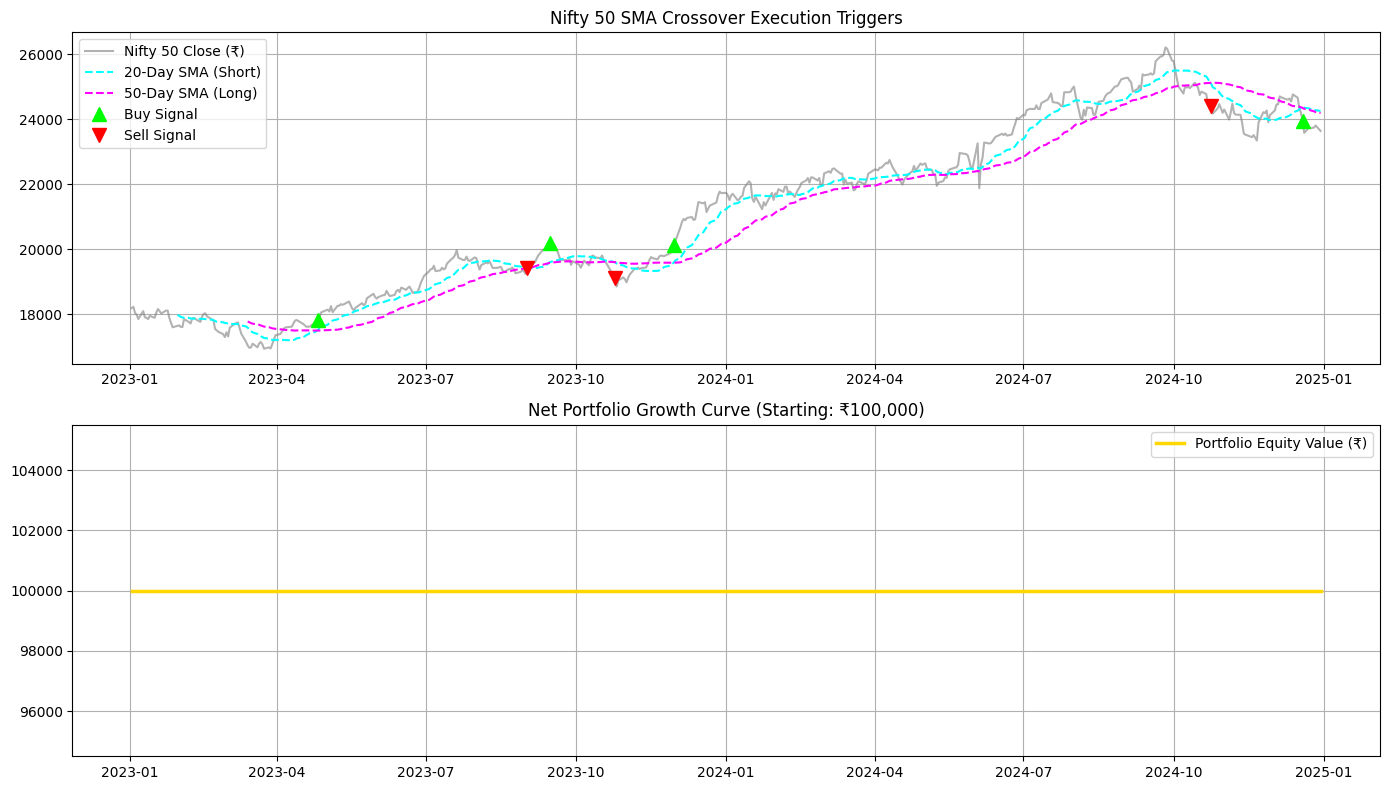

In [4]:
# Execute backtest on Nifty 50 (^NSEI)
# You can also try Sensex with '^BSESN'
df, portfolio = run_backtest_session('^NSEI', '2023-01-01', '2024-12-31', cash=100000.0)

# Plot the stock charts and performance results
plt.figure(figsize=(14, 8))

# Subplot 1: Price and SMA Crossover signals
plt.subplot(2, 1, 1)
plt.plot(df['Close'], label='Nifty 50 Close (₹)', color='grey', alpha=0.6)
plt.plot(df['SMA_Short'], label='20-Day SMA (Short)', color='cyan', linestyle='--')
plt.plot(df['SMA_Long'], label='50-Day SMA (Long)', color='magenta', linestyle='--')

# Draw green triangle markers for Buy Signals
buy_signals = df[df['Positions'] == 1.0]
plt.plot(buy_signals.index, buy_signals['Close'], '^', markersize=10, color='lime', label='Buy Signal')

# Draw red inverted triangle markers for Sell Signals
sell_signals = df[df['Positions'] == -1.0]
plt.plot(sell_signals.index, sell_signals['Close'], 'v', markersize=10, color='red', label='Sell Signal')

plt.title('Nifty 50 SMA Crossover Execution Triggers')
plt.legend()
plt.grid(True)

# Subplot 2: Capital value growth curve
plt.subplot(2, 1, 2)
plt.plot(portfolio['Total'], label='Portfolio Equity Value (₹)', color='gold', linewidth=2.5)
plt.title('Net Portfolio Growth Curve (Starting: ₹100,000)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()